In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("../data/phishing_legit_dataset_KD_10000.xlsx")

In [3]:
df.head()

,text,label,phishing_type,severity,confidence
0,Subject: Office maintenance.\n\nThanks for you...,0,legitimate,low,0.95
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69
3,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91
4,"Notice, your profile has been restricted. Use ...",1,credential_harvesting,high,0.80


In [4]:
df.shape

(10000, 5)

In [5]:
df.columns

Index(['text', 'label', 'phishing_type', 'severity', 'confidence'], dtype='str')

In [6]:
df['label'].value_counts()

label
1    6000
0    4000
Name: count, dtype: int64

In [7]:
df.isnull().sum()

text             0
label            0
phishing_type    0
severity         0
confidence       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df = df.dropna(subset=['text', 'label'])
df.shape

(10000, 5)

In [10]:
df['clean_text'] = df['text'].astype(str).str.lower().str.strip()
df[['text', 'clean_text']].head()

,text,clean_text
0,Subject: Office maintenance.\n\nThanks for you...,subject: office maintenance.\n\nthanks for you...
1,"Hello, your profile has been locked. Use the s...","hello, your profile has been locked. use the s..."
2,"Hi there, congratulations! You are the winner ...","hi there, congratulations! you are the winner ..."
3,"Attention, this is the fraud prevention accoun...","attention, this is the fraud prevention accoun..."
4,"Notice, your profile has been restricted. Use ...","notice, your profile has been restricted. use ..."


In [11]:

X = df['clean_text']
y = df['label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000,)
y shape: (10000,)


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
# Train set (80%) සහ Test set (20%) ලෙස Split කිරීම
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Total Emails: {len(df)}")
print(f"Training Emails (80%): {len(X_train)}")
print(f"Testing Emails (20%): {len(X_test)}")

Total Emails: 10000
Training Emails (80%): 8000
Testing Emails (20%): 2000


In [14]:
print("--- Training Labels Distribution ---")
print(y_train.value_counts())

print("\n--- Testing Labels Distribution ---")
print(y_test.value_counts())

--- Training Labels Distribution ---
label
1    4800
0    3200
Name: count, dtype: int64

--- Testing Labels Distribution ---
label
1    1200
0     800
Name: count, dtype: int64


In [15]:
!pip install --upgrade --force-reinstall scikit-learn

  Using cached scikit_learn-1.9.1-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached numpy-2.5.3-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.1-cp313-cp313-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached numpy-2.5.3-cp313-cp313-win_amd64.whl (12.6 MB)
Using cached scipy-1.18.1-cp313-cp313-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)

  Attempting uninstall: threadpoolctl

    Found existing installation: threadpoolctl 3.7.0

    Uninst

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from sklearn.model_selection import train_test_split

In [17]:
# Train set (80%) සහ Test set (20%) ලෙස Split කිරීම
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Total Emails: {len(df)}")
print(f"Training Emails (80%): {len(X_train)}")
print(f"Testing Emails (20%): {len(X_test)}")

Total Emails: 10000
Training Emails (80%): 8000
Testing Emails (20%): 2000


In [18]:
X = df['clean_text']
y = df['label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000,)
y shape: (10000,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Total Emails: {len(df)}")
print(f"Training Emails (80%): {len(X_train)}")
print(f"Testing Emails (20%): {len(X_test)}")

Total Emails: 10000
Training Emails (80%): 8000
Testing Emails (20%): 2000


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorizer එක සාදාගැනීම
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

In [22]:
# Training set එක TF-IDF එකට අනුව Convert කිරීම
X_train_tfidf = vectorizer.fit_transform(X_train)

print("X_train_tfidf Shape:", X_train_tfidf.shape)

X_train_tfidf Shape: (8000, 574)


In [23]:
# Testing set එක TF-IDF එකට Convert කිරීම (fit කරන්නේ නැත)
X_test_tfidf = vectorizer.transform(X_test)

print("X_test_tfidf Shape:", X_test_tfidf.shape)

X_test_tfidf Shape: (2000, 574)


In [24]:
from sklearn.naive_bayes import MultinomialNB

# Naïve Bayes Model එක සෑදීම
nb_model = MultinomialNB()

# Training Data (X_train_tfidf, y_train) යොදාගනිමින් Model එක Train කිරීම
nb_model.fit(X_train_tfidf, y_train)

print("Naïve Bayes Model Trained Successfully!")

Naïve Bayes Model Trained Successfully!


In [25]:
# Testing Data (X_test_tfidf) සඳහා Model එක හරහා Predict කිරීම
y_pred = nb_model.predict(X_test_tfidf)

print("Predictions Completed!")
print("First 10 Predictions:", y_pred[:10])
print("First 10 Actual Labels:\n", y_test.iloc[:10].values)

Predictions Completed!
First 10 Predictions: [1 0 1 1 1 1 0 1 1 1]
First 10 Actual Labels:
 [1 0 1 1 1 1 0 1 1 1]


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Evaluation Metrics ගණනය කිරීම
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%\n")

print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

Accuracy : 100.00%
Precision: 100.00%
Recall   : 100.00%
F1-Score : 100.00%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       800
           1       1.00      1.00      1.00      1200

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



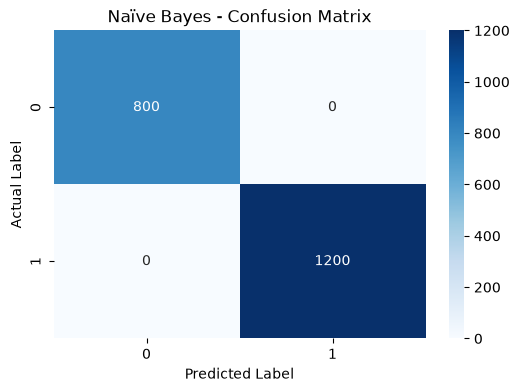

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix ගණනය කිරීම
cm = confusion_matrix(y_test, y_pred)

# Heatmap එක ලෙස ඇඳීම
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Naïve Bayes - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# Graph එක results folder එක ඇතුළේ Image එකක් ලෙස Save කරගැනීම
plt.savefig("../results/naive_bayes_confusion_matrix.png", bbox_inches='tight')
plt.show()

In [28]:
def check_phishing_rules(email_text):
    text = str(email_text).lower()
    
    # 1. Keywords Lists (ලැයිස්තු)
    urgent_keywords = ['urgent', 'immediately', 'suspended', 'action required', 'restricted', '24 hours', 'alert']
    credential_keywords = ['verify password', 'update account', 'login credential', 'confirm identity', 'security update']
    suspicious_link_patterns = ['http://', 'bit.ly', 'tinyurl', 'click here', 'login-link', 'update-link']
    financial_keywords = ['bank account', 'credit card', 'payment failed', 'transfer money', 'billing issue', 'crypto']
    
    # 2. Rule Check Counters
    detected_indicators = []
    
    # Urgent Words Check
    found_urgent = [word for word in urgent_keywords if word in text]
    if found_urgent:
        detected_indicators.append(f"Urgency Detected: {found_urgent}")
        
    # Credential Words Check
    found_credential = [word for word in credential_keywords if word in text]
    if found_credential:
        detected_indicators.append(f"Credential Request Detected: {found_credential}")
        
    # Link Patterns Check
    found_links = [pattern for pattern in suspicious_link_patterns if pattern in text]
    if found_links:
        detected_indicators.append(f"Suspicious Link/Call to Action Detected: {found_links}")
        
    # Financial Words Check
    found_financial = [word for word in financial_keywords if word in text]
    if found_financial:
        detected_indicators.append(f"Financial Request Detected: {found_financial}")
        
    # Rule Score ගණනය කිරීම
    is_phishing_by_rules = len(detected_indicators) > 0
    
    return {
        'rule_phishing': is_phishing_by_rules,
        'indicator_count': len(detected_indicators),
        'indicators': detected_indicators
    }

print("Rule-Based Detection Function Defined Successfully!")

Rule-Based Detection Function Defined Successfully!


In [29]:
# Sample Phishing Email එකක් පරීක්ෂා කර බලමු
test_email = "URGENT! Your bank account has been suspended. Click here to verify password immediately: http://fake-bank-login.com"

rule_result = check_phishing_rules(test_email)

print("--- Rule-Based Detection Output ---")
print("Is Phishing (Rule Score):", rule_result['rule_phishing'])
print("Total Indicators Found :", rule_result['indicator_count'])
print("Detected Indicators    :")
for indicator in rule_result['indicators']:
    print(" -", indicator)

--- Rule-Based Detection Output ---
Is Phishing (Rule Score): True
Total Indicators Found : 4
Detected Indicators    :
 - Urgency Detected: ['urgent', 'immediately', 'suspended']
 - Credential Request Detected: ['verify password']
 - Suspicious Link/Call to Action Detected: ['http://', 'click here']
 - Financial Request Detected: ['bank account']


In [30]:
def predict_phishing_hybrid(email_text, model, vectorizer):
    # 1. Preprocessing
    clean_text = str(email_text).lower().strip()
    
    # 2. ML Prediction (Naïve Bayes)
    text_tfidf = vectorizer.transform([clean_text])
    ml_prediction = model.predict(text_tfidf)[0]
    ml_label = "Phishing" if ml_prediction == 1 else "Legitimate"
    
    # 3. Rule-Based Detection
    rule_result = check_phishing_rules(clean_text)
    rule_label = "Phishing" if rule_result['rule_phishing'] else "Legitimate"
    
    # 4. Combine Results (Hybrid Logic)
    if ml_prediction == 1 or rule_result['rule_phishing']:
        final_result = "Phishing"
        risk_level = "High Risk" if (ml_prediction == 1 and rule_result['rule_phishing']) else "Medium Risk"
    else:
        final_result = "Legitimate"
        risk_level = "Low Risk / Safe"
        
    return {
        'email_text': email_text,
        'final_result': final_result,
        'risk_level': risk_level,
        'ml_prediction': ml_label,
        'rule_prediction': rule_label,
        'detected_indicators': rule_result['indicators']
    }

print("Hybrid Phishing Detector Function Ready!")

Hybrid Phishing Detector Function Ready!


In [31]:
# Sample Email 1: Complex Phishing Email
sample_phishing = "Action Required: Your Microsoft account was accessed from a new device. Update password immediately at http://verify-microsft.com"

# Sample Email 2: Legitimate Email
sample_legit = "Hi team, please find attached the weekly summary report for our upcoming project meeting tomorrow."

print("=== TEST 1: PHISHING EMAIL ===")
res1 = predict_phishing_hybrid(sample_phishing, nb_model, vectorizer)
print(f"Final Result : {res1['final_result']} ({res1['risk_level']})")
print(f"ML Output    : {res1['ml_prediction']}")
print(f"Rule Output  : {res1['rule_prediction']}")
print(f"Indicators   : {res1['detected_indicators']}\n")

print("=== TEST 2: LEGITIMATE EMAIL ===")
res2 = predict_phishing_hybrid(sample_legit, nb_model, vectorizer)
print(f"Final Result : {res2['final_result']} ({res2['risk_level']})")
print(f"ML Output    : {res2['ml_prediction']}")
print(f"Rule Output  : {res2['rule_prediction']}")

=== TEST 1: PHISHING EMAIL ===
Final Result : Phishing (High Risk)
ML Output    : Phishing
Rule Output  : Phishing
Indicators   : ["Urgency Detected: ['immediately', 'action required']", "Suspicious Link/Call to Action Detected: ['http://']"]

=== TEST 2: LEGITIMATE EMAIL ===
Final Result : Legitimate (Low Risk / Safe)
ML Output    : Legitimate
Rule Output  : Legitimate


In [32]:
# Test Case Emails (Phishing Types සහ Legitimate Emails)
test_cases = [
    {
        "type": "Urgent Banking Phishing",
        "text": "URGENT: Your Bank Account has been frozen due to suspicious activity. Verify credentials immediately: http://bit.ly/bank-sec"
    },
    {
        "type": "Credential Harvesting Phishing",
        "text": "Your Netflix billing payment failed. Update credit card details and confirm identity now: http://login-update.com"
    },
    {
        "type": "Lottery / Prize Phishing",
        "text": "Congratulations! You won $10,000 cash prize. Click here to claim money transfer now!"
    },
    {
        "type": "Legitimate Office Email",
        "text": "Hi team, please find attached the weekly summary report for our upcoming project meeting tomorrow."
    },
    {
        "type": "Legitimate Notification",
        "text": "Your monthly electricity bill receipt is ready for download in your online account portal."
    }
]

# Results Display කිරීම
print("=================== HYBRID TESTING RESULTS ===================\n")
for idx, case in enumerate(test_cases, 1):
    res = predict_phishing_hybrid(case['text'], nb_model, vectorizer)
    print(f"Test #{idx} [{case['type']}]")
    print(f"Email Text : {case['text'][:75]}...")
    print(f"Result     : {res['final_result']} ({res['risk_level']})")
    print(f"ML Model   : {res['ml_prediction']} | Rules: {res['rule_prediction']}")
    print(f"Indicators : {res['detected_indicators']}")
    print("-" * 60)

=================== HYBRID TESTING RESULTS ===================

Test #1 [Urgent Banking Phishing]
Email Text : URGENT: Your Bank Account has been frozen due to suspicious activity. Verif...
Result     : Phishing (High Risk)
ML Model   : Phishing | Rules: Phishing
Indicators : ["Urgency Detected: ['urgent', 'immediately']", "Suspicious Link/Call to Action Detected: ['http://', 'bit.ly']", "Financial Request Detected: ['bank account']"]
------------------------------------------------------------
Test #2 [Credential Harvesting Phishing]
Email Text : Your Netflix billing payment failed. Update credit card details and confirm...
Result     : Phishing (High Risk)
ML Model   : Phishing | Rules: Phishing
Indicators : ["Credential Request Detected: ['confirm identity']", "Suspicious Link/Call to Action Detected: ['http://']", "Financial Request Detected: ['credit card', 'payment failed']"]
------------------------------------------------------------
Test #3 [Lottery / Prize Phishing]
Email Tex

In [33]:
# Testing Set (20%) එක සඳහා Hybrid System එකේ Predictions සෑදීම
hybrid_preds = []

for text in X_test:
    res = predict_phishing_hybrid(text, nb_model, vectorizer)
    # Convert 'Phishing' -> 1 and 'Legitimate' -> 0 for evaluation
    pred_val = 1 if res['final_result'] == 'Phishing' else 0
    hybrid_preds.append(pred_val)

# False Positives සහ False Negatives ගණනය කිරීම
fp = 0 # False Positive: Actual Legit, Predicted Phishing
fn = 0 # False Negative: Actual Phishing, Predicted Legit

for actual, pred in zip(y_test, hybrid_preds):
    if actual == 0 and pred == 1:
        fp += 1
    elif actual == 1 and pred == 0:
        fn += 1

print("--- Error Analysis (False Positives / False Negatives) ---")
print(f"Total Test Emails : {len(y_test)}")
print(f"False Positives (FP) : {fp} (සාමාන්‍ය Email එකක් Phishing ලෙස වැරදීම)")
print(f"False Negatives (FN) : {fn} (Phishing Email එකක් සාමාන්‍ය එකක් ලෙස වැරදීම)")

--- Error Analysis (False Positives / False Negatives) ---
Total Test Emails : 2000
False Positives (FP) : 0 (සාමාන්‍ය Email එකක් Phishing ලෙස වැරදීම)
False Negatives (FN) : 0 (Phishing Email එකක් සාමාන්‍ය එකක් ලෙස වැරදීම)


In [34]:
import joblib

# 1. Model එක සහ Vectorizer එක models folder එක ඇතුළට save කිරීම
joblib.dump(nb_model, '../models/naive_bayes_model.pkl')
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')

print("Model and Vectorizer saved successfully inside 'models/' folder!")

Model and Vectorizer saved successfully inside 'models/' folder!


In [35]:
# Metrics dictionary එකක් ලෙස සෑදීම
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'False Positives', 'False Negatives'],
    'Value': [
        f"{accuracy * 100:.2f}%",
        f"{precision * 100:.2f}%",
        f"{recall * 100:.2f}%",
        f"{f1 * 100:.2f}%",
        fp,
        fn
    ]
}

# DataFrame එකක් සාදා results folder එක ඇතුළේ CSV ලෙස save කිරීම
metrics_df = pd.DataFrame(metrics_data)
metrics_df.to_csv('../results/final_model_metrics.csv', index=False)

print("--- FINAL SUMMARY METRICS ---")
print(metrics_df)
print("\nMetrics saved to 'results/final_model_metrics.csv'")

--- FINAL SUMMARY METRICS ---
            Metric    Value
0         Accuracy  100.00%
1        Precision  100.00%
2           Recall  100.00%
3         F1-Score  100.00%
4  False Positives        0
5  False Negatives        0

Metrics saved to 'results/final_model_metrics.csv'


C:\Users\User\AppData\Local\Temp\ipykernel_9076\3550905799.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1-Score'],


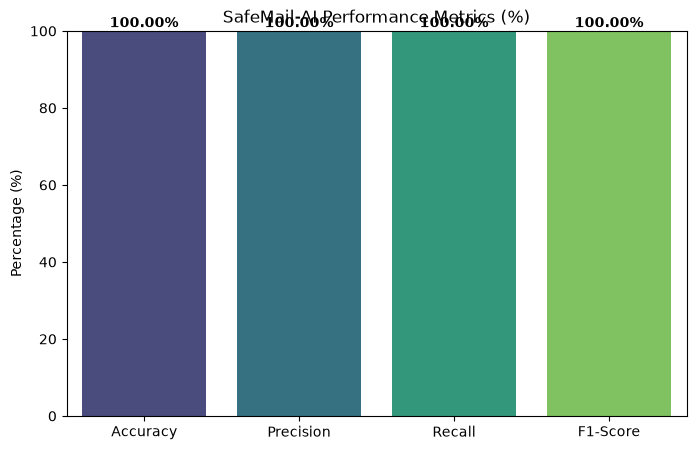

In [36]:
# Metrics Visualization Chart
plt.figure(figsize=(8, 5))
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1-Score'], 
            y=[accuracy*100, precision*100, recall*100, f1*100], 
            palette='viridis')

plt.title('SafeMail-AI Performance Metrics (%)')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)

for index, value in enumerate([accuracy*100, precision*100, recall*100, f1*100]):
    plt.text(index, value + 1, f"{value:.2f}%", ha='center', fontweight='bold')

# Save Graph
plt.savefig("../results/model_performance_summary.png", bbox_inches='tight')
plt.show()